# Single-run enzyme explorer plots

Load one generated-sequences CSV and create the three enzyme-explorer style plots for a single dataset:

- Boxplot
- Violin plot
- Threshold counts

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

thresholds = [0.3, 0.5, 0.7, 0.9]
diffusion_iterations = 1000

# Preferred score columns in priority order.
candidate_score_columns = [
    "isTPS",
    "isTPS ",
    "score",
    "prediction",
    "probability",
]

# Sequence-length runs generated with iter1000.
run_roots = [
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen200_n100_iter1000",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen300_n100_iter1000",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen400_n100_iter1000",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen500_n100_iter1000",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen600_n100_iter1000",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen700_n100_iter1000",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen800_n100_iter1000",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen100_n100_iter1000",
]

evaluation_sets = []
for root in run_roots:
    run_dir = Path(root)
    label = next(part for part in run_dir.name.split("_") if part.startswith("seqlen"))
    csv_path = run_dir / "generated_sequences" / "generated_sequences_enzyme_explorer_sequence_only.csv"
    evaluation_sets.append({"label": label, "csv_path": csv_path})

# Keep labels ordered by numeric sequence length.
evaluation_sets = sorted(evaluation_sets, key=lambda item: int(item["label"].replace("seqlen", "")))
selected_evaluations = evaluation_sets

print(f"Selected labels: {[entry['label'] for entry in selected_evaluations]}")
print(f"Diffusion iterations: {diffusion_iterations}")
for entry in selected_evaluations:
    print(entry["csv_path"])

Selected labels: ['seqlen100', 'seqlen200', 'seqlen300', 'seqlen400', 'seqlen500', 'seqlen600', 'seqlen700', 'seqlen800']
Diffusion iterations: 1000
/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen100_n100_iter1000/generated_sequences/generated_sequences_enzyme_explorer_sequence_only.csv
/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen200_n100_iter1000/generated_sequences/generated_sequences_enzyme_explorer_sequence_only.csv
/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TP

In [2]:
def detect_score_column(df, preferred_columns):
    normalized_to_original = {col.strip().lower(): col for col in df.columns}
    for candidate in preferred_columns:
        key = candidate.strip().lower()
        if key in normalized_to_original:
            return normalized_to_original[key]

    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_columns:
        raise ValueError("No numeric columns available to plot.")
    return numeric_columns[0]


records = []
score_columns_by_label = {}
plot_labels = [entry["label"] for entry in selected_evaluations]

for entry in selected_evaluations:
    label = entry["label"]
    csv_path = entry["csv_path"]

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV file not found for '{label}': {csv_path}")

    df = pd.read_csv(csv_path)
    score_column = detect_score_column(df, candidate_score_columns)
    values = pd.to_numeric(df[score_column], errors="coerce").dropna()

    if values.empty:
        raise ValueError(
            f"Column '{score_column}' in '{label}' has no numeric values after cleanup."
        )

    score_columns_by_label[label] = score_column
    records.extend((label, value) for value in values)

    print(f"Loaded '{label}': {csv_path}")
    print(
        f"Rows: {len(df):,} | Numeric values used: {len(values):,} | Score column: {score_column}"
    )


plot_df = pd.DataFrame(records, columns=["label", "score"])
distinct_score_columns = sorted(set(score_columns_by_label.values()))
value_col = distinct_score_columns[0] if len(distinct_score_columns) == 1 else "score"

print(f"Plot labels: {plot_labels}")
print(f"Detected score columns by label: {score_columns_by_label}")
print()
print(plot_df.groupby("label")["score"].describe(percentiles=[0.25, 0.5, 0.75]).to_string())

Loaded 'seqlen100': /Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen100_n100_iter1000/generated_sequences/generated_sequences_enzyme_explorer_sequence_only.csv
Rows: 100 | Numeric values used: 100 | Score column: isTPS 
Loaded 'seqlen200': /Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07/seq_len_analysis/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_N-Step-Checkpoint_epoch-172_step-20000_seqlen200_n100_iter1000/generated_sequences/generated_sequences_enzyme_explorer_sequence_only.csv
Rows: 100 | Numeric values used: 100 | Score column: isTPS 
Loaded 'seqlen300': /Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05

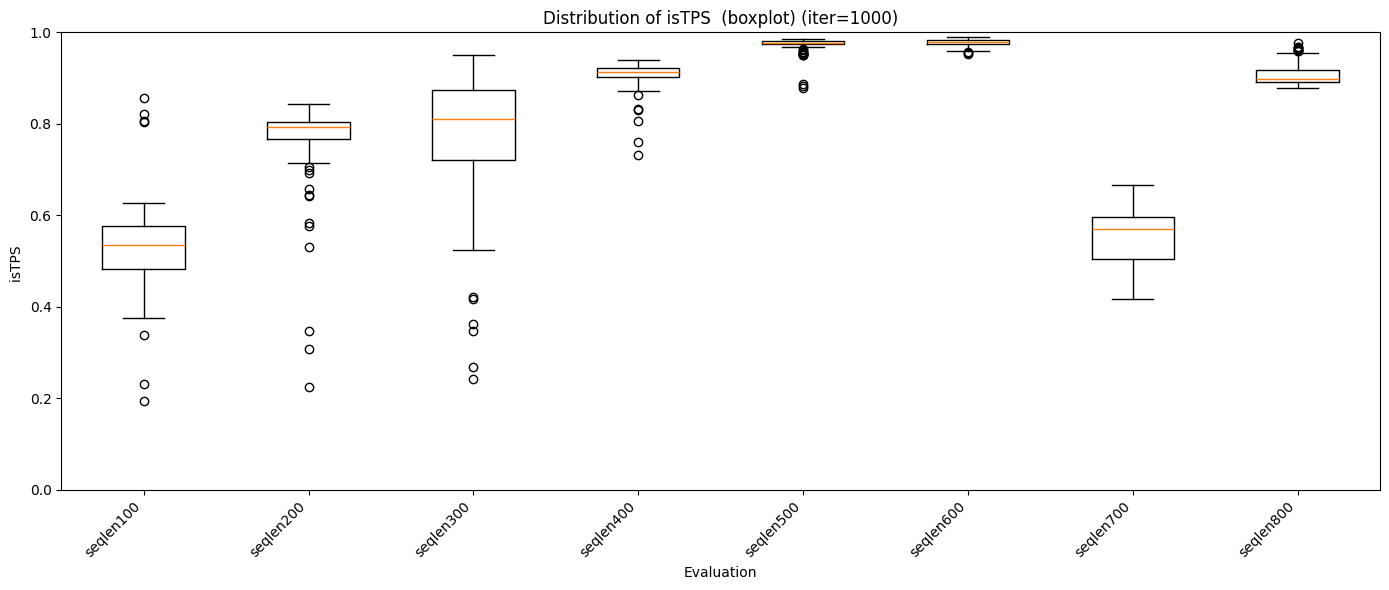

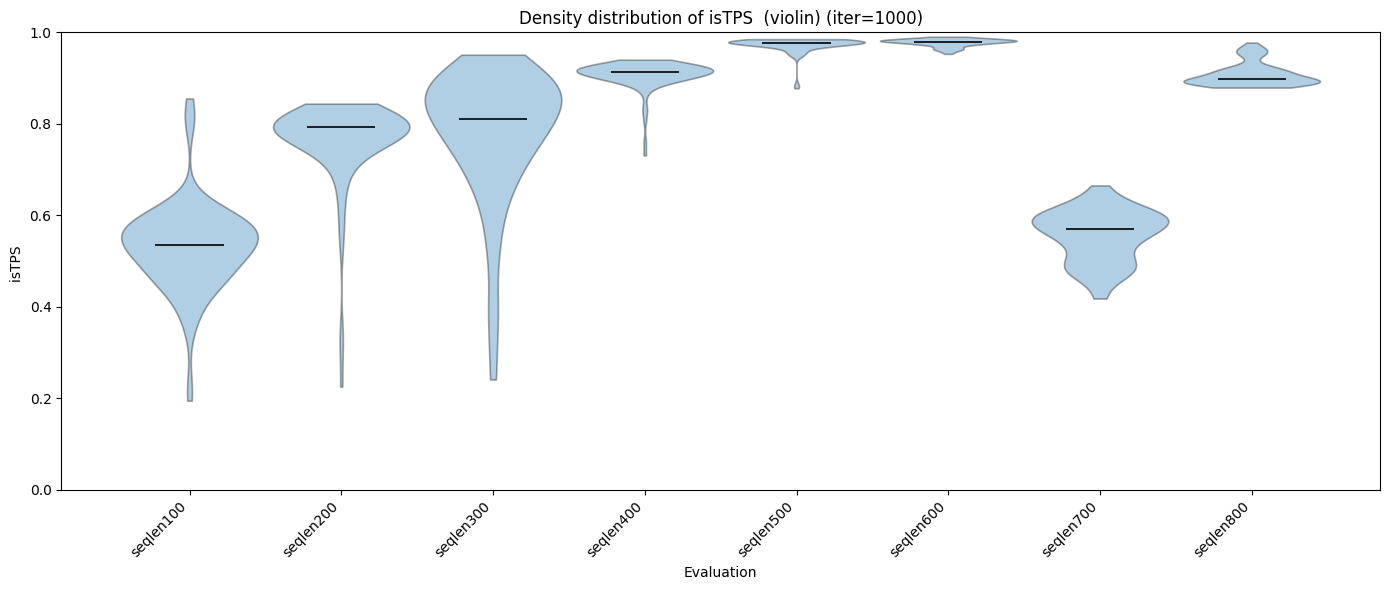

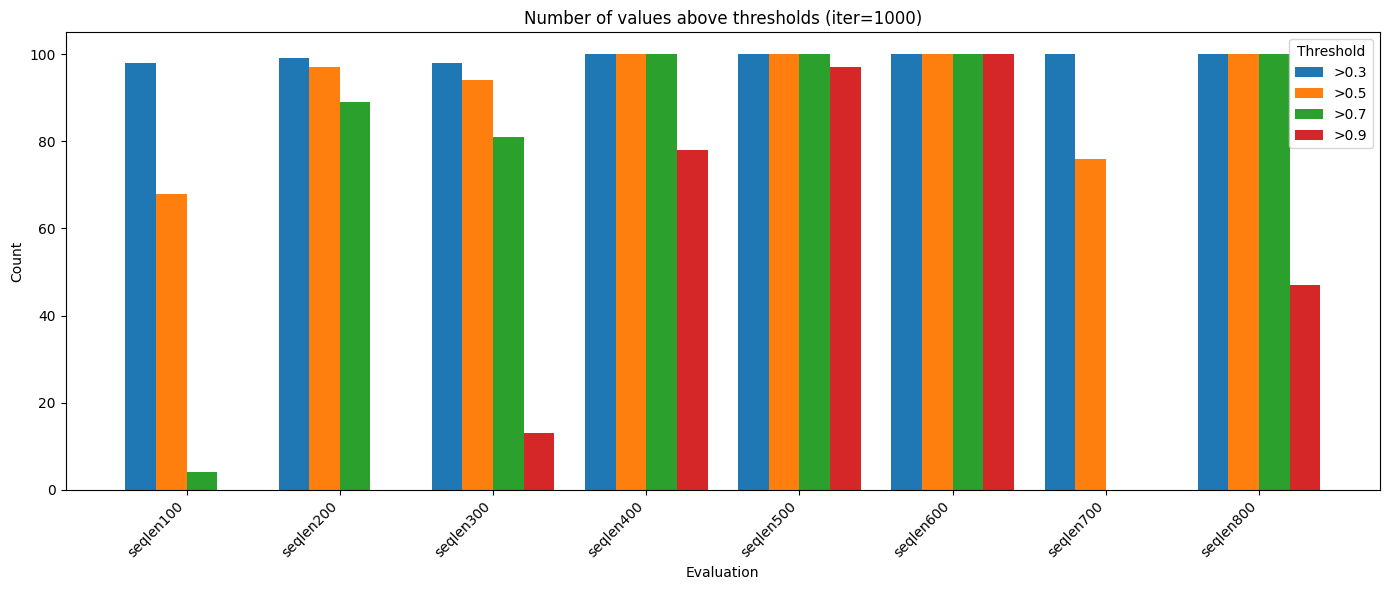

,>0.3,>0.5,>0.7,>0.9
seqlen100,98,68,4,0
seqlen200,99,97,89,0
seqlen300,98,94,81,13
seqlen400,100,100,100,78
seqlen500,100,100,100,97
seqlen600,100,100,100,100
seqlen700,100,76,0,0
seqlen800,100,100,100,47


In [3]:
import numpy as np
import pandas as pd

title_suffix = f" (iter={diffusion_iterations})"

# --- 1) Boxplot (match original styling: default black lines) ---
box_data = [
    plot_df.loc[plot_df["label"] == label, "score"].dropna().values
    for label in plot_labels
]
fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(box_data, tick_labels=plot_labels)
ax.set_title(f"Distribution of {value_col} (boxplot){title_suffix}")
ax.set_xlabel("Evaluation")
ax.set_ylabel(value_col)
ax.set_ylim(0.0, 1.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- 2) Violin (match original styling colors) ---
violin_data = [
    pd.to_numeric(
        plot_df.loc[plot_df["label"] == label, "score"],
        errors="coerce",
    ).dropna().values
    for label in plot_labels
]

fig3, ax3 = plt.subplots(figsize=(14, 6))
parts = ax3.violinplot(
    violin_data,
    positions=np.arange(1, len(plot_labels) + 1),
    widths=0.9,
    showmeans=False,
    showmedians=True,
    showextrema=False,
)

for body in parts["bodies"]:
    body.set_facecolor("#1f77b4")
    body.set_alpha(0.35)
    body.set_edgecolor("black")
    body.set_linewidth(1.2)

parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(1.2)

ax3.set_title(f"Density distribution of {value_col} (violin){title_suffix}")
ax3.set_xlabel("Evaluation")
ax3.set_ylabel(value_col)
ax3.set_ylim(0.0, 1.0)
ax3.set_xticks(np.arange(1, len(plot_labels) + 1))
ax3.set_xticklabels(plot_labels, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- 3) Threshold counts (match original styling: different colors per threshold) ---
counts = pd.DataFrame(index=plot_labels)
for threshold in thresholds:
    counts[f">{threshold}"] = [
        int((plot_df.loc[plot_df["label"] == label, "score"] > threshold).sum())
        for label in plot_labels
    ]

x = np.arange(len(counts.index))
width = 0.2

fig2, ax2 = plt.subplots(figsize=(14, 6))
for index, column in enumerate(counts.columns):
    ax2.bar(
        x + (index - (len(counts.columns) - 1) / 2) * width,
        counts[column].values,
        width=width,
        label=column,
    )

ax2.set_title(f"Number of values above thresholds{title_suffix}")
ax2.set_xlabel("Evaluation")
ax2.set_ylabel("Count")
ax2.set_xticks(x)
ax2.set_xticklabels(counts.index, rotation=45, ha="right")
ax2.legend(title="Threshold")
plt.tight_layout()
plt.show()

counts